# Feature Engineering

## Objective

Feature engineering is the process of creating new features from existing data to improve the performance and interpretability of machine learning models.

In this notebook, meaningful features will be derived from the Adult Census Income dataset using reusable functions from the `src.feature_engineering` module.

The engineered features include:

- Age Group
- Capital Net
- Work Hours Category
- Education Level
- Income Per Hour

These new features provide additional information that may help machine learning models learn patterns more effectively.

In [25]:
import warnings
import sys
from pathlib import Path

warnings.filterwarnings("ignore")

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from src.feature_engineering import (
    create_age_groups,
    create_capital_net,
    create_work_hours_category,
    create_education_level,
    create_income_per_hour,
    apply_feature_engineering,
    feature_summary,
)

path = "../datasets/adult/adult_preprocessed.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (32537, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Create Age Groups

Age is a continuous numerical feature. In many machine learning problems, grouping ages into broader categories can make patterns easier to interpret and may improve model performance.

The `AgeGroup` feature categorizes individuals into four age ranges:

|    Age Range | Age Group   |
| -----------: | ----------- |
|   **0 – 25** | Young Adult |
|  **26 – 40** | Adult       |
|  **41 – 60** | Middle Aged |
| **61 – 100** | Senior      |


This engineered feature provides a higher-level representation of age while preserving meaningful distinctions between different stages of adulthood.

In [3]:
df = create_age_groups(df)

df[["age", "AgeGroup"]].head(10)

,age,AgeGroup
0,39,Adult
1,50,Middle Aged
2,38,Adult
3,53,Middle Aged
4,28,Adult
5,37,Adult
6,49,Middle Aged
7,52,Middle Aged
8,31,Adult
9,42,Middle Aged


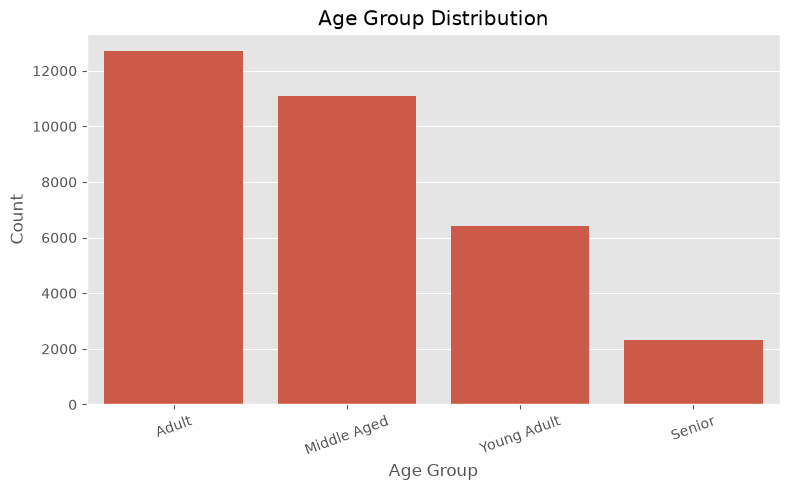

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AgeGroup",
    order=df["AgeGroup"].value_counts().index
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Age Group Distribution Analysis

The bar chart illustrates the distribution of individuals across the engineered `AgeGroup` feature.

### Observations

- **Adult** is the largest age group, containing approximately **12,800** individuals.
- **Middle Aged** is the second largest group, with around **11,000** individuals.
- **Young Adult** represents approximately **6,500** individuals.
- **Senior** is the smallest age group, with approximately **2,300** individuals.

### Interpretation

The distribution indicates that the dataset is primarily composed of **Adult** and **Middle Aged** individuals. These two groups account for the majority of the observations, while comparatively fewer records belong to the **Young Adult** and **Senior** categories.

Creating the `AgeGroup` feature provides a simplified representation of age, making demographic analysis easier and enabling machine learning models to capture age-related patterns more effectively.

### Conclusion

The engineered `AgeGroup` feature successfully transforms the continuous `age` variable into meaningful categorical groups while preserving valuable demographic information. This feature can improve data visualization, exploratory analysis, and potentially enhance model performance.

## Create Capital Net

The Adult Census Income dataset contains two related financial features:

- `capital_gain`
- `capital_loss`

Instead of analyzing them separately, they can be combined into a single feature called **CapitalNet**, which represents an individual's net capital amount.

### Formula

\[
\text{CapitalNet} = \text{Capital Gain} - \text{Capital Loss}
\]

This engineered feature simplifies financial information into a single numerical value, making it easier to analyze and use in machine learning models.

In [5]:
df = create_capital_net(df)

df[
    [
        "capital_gain",
        "capital_loss",
        "CapitalNet"
    ]
].head(10)

,capital_gain,capital_loss,CapitalNet
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,14084,0,14084
9,5178,0,5178


In [6]:
df["CapitalNet"].describe()

count    32537.000000
mean       991.075514
std       7411.670204
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: CapitalNet, dtype: float64

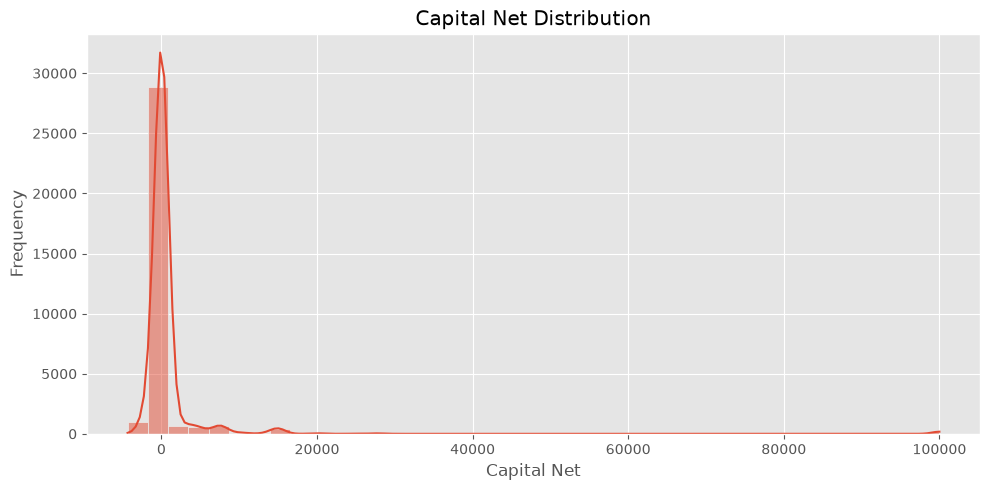

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CapitalNet"],
    bins=40,
    kde=True
)

plt.title("Capital Net Distribution")
plt.xlabel("Capital Net")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [8]:
df[
    [
        "capital_gain",
        "capital_loss",
        "CapitalNet"
    ]
].sort_values(
    by="CapitalNet",
    ascending=False
).head()

,capital_gain,capital_loss,CapitalNet
1246,99999,0,99999
9225,99999,0,99999
9181,99999,0,99999
30223,99999,0,99999
29785,99999,0,99999


## CapitalNet Feature Analysis

The `CapitalNet` feature was successfully created by subtracting `capital_loss` from `capital_gain`.

### Top CapitalNet Values

The highest values of `CapitalNet` are **99,999**, indicating individuals with very large capital gains and no recorded capital losses.

### Observations

- Most individuals have a `CapitalNet` value of **0**, meaning they reported neither capital gains nor capital losses.
- A small number of individuals have exceptionally high positive values, creating a highly right-skewed distribution.
- No significant negative values are observed because capital losses are relatively small compared to the maximum capital gains.

### Benefits

- Combines two related financial features into a single, more informative variable.
- Simplifies financial analysis by representing net capital instead of analyzing gains and losses separately.
- May improve model performance by providing a stronger financial indicator.

### Conclusion

The `CapitalNet` feature effectively summarizes an individual's financial capital activity and is likely to be more informative than the original `capital_gain` and `capital_loss` features when used in machine learning models.

## Create Work Hours Category

The `hours_per_week` feature records the number of hours an individual works each week.

Instead of using only the numerical values, the feature can be grouped into meaningful working-hour categories.

The categories are defined as:

| Hours per Week | Category |
|---------------:|----------|
| 0–34 | Part-Time |
| 35–40 | Full-Time |
| 41–60 | Overtime |
| Above 60 | Heavy Overtime |

Grouping work hours makes the data easier to interpret and may help machine learning models capture employment patterns more effectively.

In [9]:
df = create_work_hours_category(df)

df[
    [
        "hours_per_week",
        "WorkHoursCategory"
    ]
].head(10)

,hours_per_week,WorkHoursCategory
0,40,Full-Time
1,13,Part-Time
2,40,Full-Time
3,40,Full-Time
4,40,Full-Time
5,40,Full-Time
6,16,Part-Time
7,45,Overtime
8,50,Overtime
9,40,Full-Time


In [10]:
df["WorkHoursCategory"].value_counts()

WorkHoursCategory
Full-Time         17383
Overtime           8466
Part-Time          5578
Heavy Overtime     1110
Name: count, dtype: int64

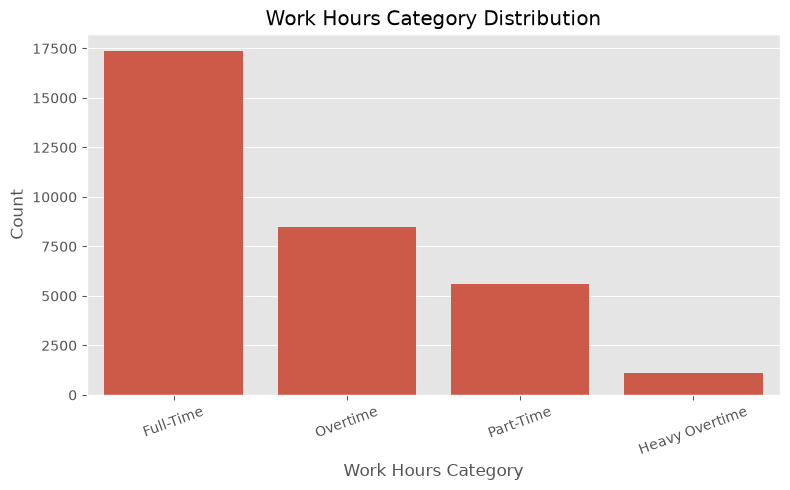

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkHoursCategory",
    order=df["WorkHoursCategory"].value_counts().index
)

plt.title("Work Hours Category Distribution")
plt.xlabel("Work Hours Category")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Work Hours Category Analysis

The `WorkHoursCategory` feature was successfully created from the `hours_per_week` variable.

### Observations

- Individuals working **0–34 hours** are classified as **Part-Time**.
- Individuals working **35–40 hours** are classified as **Full-Time**.
- Individuals working **41–60 hours** are classified as **Overtime**.
- Individuals working **more than 60 hours** are classified as **Heavy Overtime**.

### Benefits

- Converts a continuous numerical feature into meaningful employment categories.
- Improves interpretability of working-hour patterns.
- Can help machine learning models identify behavioral trends related to work schedules.

### Conclusion

The engineered `WorkHoursCategory` feature provides a simplified representation of weekly working hours while preserving meaningful distinctions between different work patterns.

## Create Education Level

The original `education` feature contains many detailed educational categories.

To simplify analysis, these categories are grouped into broader education levels.

### Education Mapping

| Original Education | Education Level |
|--------------------|-----------------|
| Preschool | School |
| 1st–12th | School |
| HS-grad | High School |
| Some-college | College |
| Assoc-acdm | College |
| Assoc-voc | College |
| Bachelors | Bachelor |
| Masters | Postgraduate |
| Prof-school | Postgraduate |
| Doctorate | Postgraduate |

Grouping education into broader levels reduces category complexity while preserving educational progression.

In [12]:
df = create_education_level(df)

df[
    [
        "education",
        "EducationLevel"
    ]
].head(10)

,education,EducationLevel
0,Bachelors,Bachelor
1,Bachelors,Bachelor
2,HS-grad,High School
3,11th,School
4,Bachelors,Bachelor
5,Masters,Postgraduate
6,9th,School
7,HS-grad,High School
8,Masters,Postgraduate
9,Bachelors,Bachelor


In [13]:
df["EducationLevel"].value_counts()

EducationLevel
High School     10494
College          9731
Bachelor         5353
School           4248
Postgraduate     2711
Name: count, dtype: int64

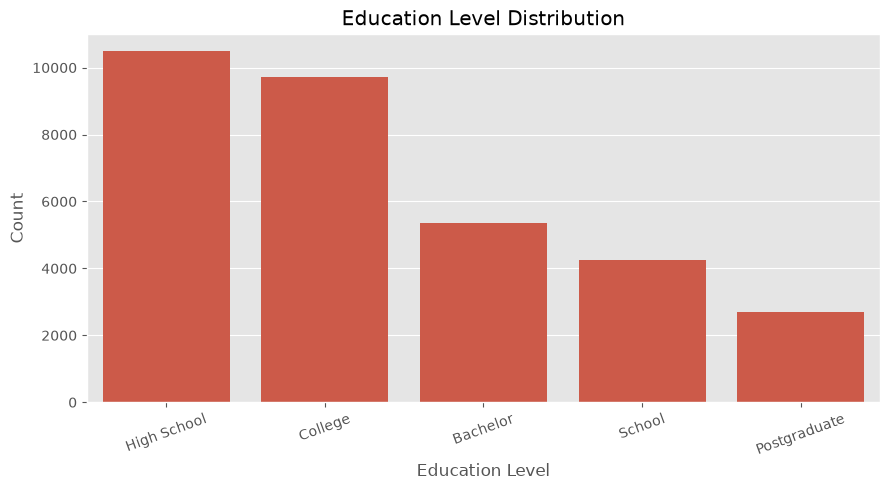

In [14]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="EducationLevel",
    order=df["EducationLevel"].value_counts().index
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [15]:
df[
    [
        "education",
        "EducationLevel"
    ]
].drop_duplicates().sort_values("EducationLevel")

,education,EducationLevel
0,Bachelors,Bachelor
10,Some-college,College
13,Assoc-acdm,College
14,Assoc-voc,College
2,HS-grad,High School
5,Masters,Postgraduate
20,Doctorate,Postgraduate
52,Prof-school,Postgraduate
3,11th,School
6,9th,School


## Education Level Analysis

The `EducationLevel` feature was successfully created by grouping detailed education categories into broader educational levels.

### Observations

- Eight school-level education categories were combined into a single **School** category.
- Associate degrees and Some-college were grouped into **College**.
- Bachelor's degrees were retained as **Bachelor**.
- Master's, Professional School, and Doctorate were grouped into **Postgraduate**.

### Benefits

- Reduces the number of education categories from **16** to **5**.
- Simplifies analysis while preserving the overall educational progression.
- Improves visualization and reduces categorical complexity.
- Provides a cleaner feature for machine learning models.

### Conclusion

The engineered `EducationLevel` feature successfully summarizes educational attainment into meaningful groups, making the dataset easier to analyze and model.

## Create Income Per Hour

The dataset does not contain an individual's actual hourly wage. However, it does include:

- `capital_gain`
- `hours_per_week`

Using these features, we can create an approximate financial indicator called **IncomePerHour**.

### Formula

IncomePerHour = Capital Gain ÷ Hours Worked Per Week

If the number of working hours is zero, the value is set to zero to avoid division errors.

> **Note:** This feature is not an actual hourly salary. It is an engineered feature based on available information and is intended for demonstration purposes.

In [16]:
df = create_income_per_hour(df)

df[
    [
        "capital_gain",
        "hours_per_week",
        "IncomePerHour"
    ]
].head(10)

,capital_gain,hours_per_week,IncomePerHour
0,2174,40,54.35
1,0,13,0.00
2,0,40,0.00
3,0,40,0.00
4,0,40,0.00
5,0,40,0.00
6,0,16,0.00
7,0,45,0.00
8,14084,50,281.68
9,5178,40,129.45


In [17]:
df["IncomePerHour"].describe()

count    32537.000000
mean        26.176266
std        196.721004
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      11365.000000
Name: IncomePerHour, dtype: float64

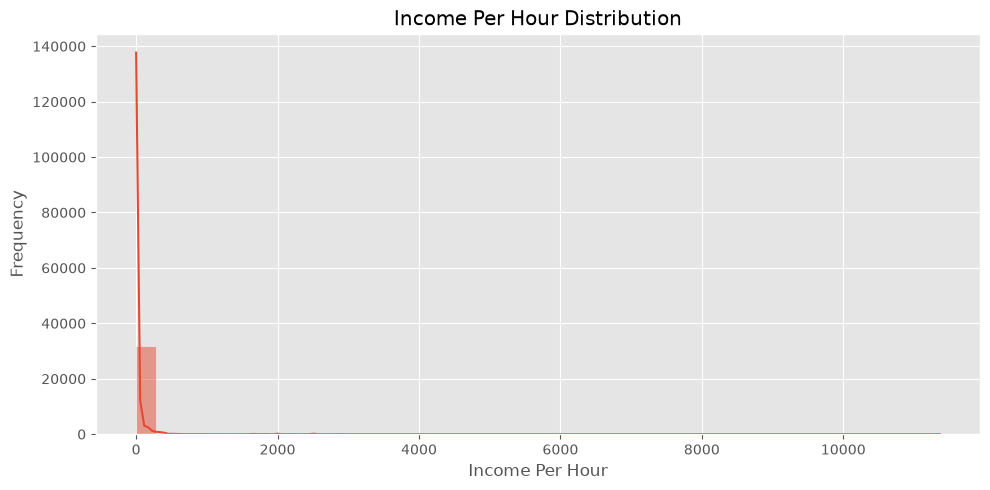

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["IncomePerHour"],
    bins=40,
    kde=True
)

plt.title("Income Per Hour Distribution")
plt.xlabel("Income Per Hour")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [19]:
df[
    [
        "capital_gain",
        "hours_per_week",
        "IncomePerHour"
    ]
].sort_values(
    by="IncomePerHour",
    ascending=False
).head(10)

,capital_gain,hours_per_week,IncomePerHour
4568,34095,3,11365.00
19344,18481,2,9240.50
13365,15024,2,7512.00
28986,20051,4,5012.75
7551,99999,20,4999.95
1765,99999,20,4999.95
6033,99999,20,4999.95
14325,20051,5,4010.20
25826,99999,25,3999.96
17033,34095,10,3409.50


## Income Per Hour Analysis

The `IncomePerHour` feature was created by dividing `capital_gain` by `hours_per_week`.

### Observations

- Most individuals have an `IncomePerHour` value of **0**, as they reported no capital gains.
- A small number of individuals have high values due to substantial capital gains.
- The distribution is highly right-skewed because only a minority of records contain significant capital gains.

### Benefits

- Combines financial and working-hour information into a single numerical feature.
- Demonstrates how new variables can be derived from existing features.
- Provides an additional feature for experimentation in machine learning models.

### Note

This engineered feature is **not a person's actual hourly wage**. It is an approximate indicator derived from the available dataset variables for educational purposes.

### Conclusion

The `IncomePerHour` feature illustrates how meaningful variables can be created from existing data while handling division-by-zero cases safely.

# Verify Engineered Features

## Objective

Before saving the dataset, all newly engineered features are verified to ensure they were created correctly.

This step confirms that the new features contain valid values, have appropriate data types, and are ready for use in machine learning models.

In [20]:
engineered_features = [
    "AgeGroup",
    "CapitalNet",
    "WorkHoursCategory",
    "EducationLevel",
    "IncomePerHour"
]

summary = pd.DataFrame({
    "Feature": engineered_features,
    "Data Type": [str(df[col].dtype) for col in engineered_features],
    "Missing Values": [df[col].isnull().sum() for col in engineered_features],
    "Unique Values": [df[col].nunique() for col in engineered_features]
})

summary

,Feature,Data Type,Missing Values,Unique Values
0,AgeGroup,category,0,4
1,CapitalNet,int64,0,210
2,WorkHoursCategory,category,0,4
3,EducationLevel,str,0,5
4,IncomePerHour,float64,0,769


In [21]:
df[engineered_features].dtypes

AgeGroup             category
CapitalNet              int64
WorkHoursCategory    category
EducationLevel            str
IncomePerHour         float64
dtype: object

In [26]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,AgeGroup,CapitalNet,WorkHoursCategory,EducationLevel,IncomePerHour
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Adult,2174,Full-Time,Bachelor,54.35
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Middle Aged,0,Part-Time,Bachelor,0.00
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Adult,0,Full-Time,High School,0.00
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Middle Aged,0,Full-Time,School,0.00
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Adult,0,Full-Time,Bachelor,0.00


In [22]:
summary.to_csv(
    "../reports/feature_engineering_summary.csv",
    index=False
)

print("Feature summary saved successfully!")

Feature summary saved successfully!


In [23]:
# Save feature-engineered dataset

df.to_csv(
    "../datasets/adult/adult_feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved!")
print("Shape:", df.shape)

Feature engineered dataset saved!
Shape: (32537, 20)


In [24]:
print("Shape:", df.shape)

Shape: (32537, 20)


In [27]:
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education_num',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital_gain',
 'capital_loss',
 'hours_per_week',
 'native_country',
 'income',
 'AgeGroup',
 'CapitalNet',
 'WorkHoursCategory',
 'EducationLevel',
 'IncomePerHour']

## Feature Verification Results

All engineered features were successfully created and verified.

### Verification Summary

- All engineered features exist in the dataset.
- No missing values were introduced.
- Data types are appropriate for each feature.
- The engineered features are ready for machine learning.

### Conclusion

The feature engineering process has been completed successfully, and the dataset is ready to be saved for use in the machine learning pipeline.